# ASAP8 Detection of Change analysis

Minimal setup for cross-session Detection-of-Change analyses. This notebook deliberately stops before plotting or inferential analysis.

Canonical tables created here:
- `sessions`: one row per complete processed session
- `rois`: one row per session-specific ROI, including longitudinal identity and depth group
- `spikes`: canonical `template_v1` optical-spike table
- `events`: one row per expected image cycle, with independent change/omission marker times
- `trial_index`: lightweight map from single-trial H5 rows onto `events`

Mean-response, sequence-response, single-trial, and running loaders are imported for the analysis cells that follow.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.voltage.dataset import (
    DEPTH_GROUP_ORDER,
    build_voltage_session_table,
    build_voltage_roi_table,
)
from vip_slap2_analysis.voltage.spikes import (
    DETECTOR_VERSION,
    build_spike_table,
)
from vip_slap2_analysis.behavior.change_detection import build_change_detection_events
from vip_slap2_analysis.voltage.responses import (
    build_single_trial_index,
    load_response_package,
    get_mean_response,
    get_sequence_response,
    load_single_trial_traces,
)
from vip_slap2_analysis.behavior.encoder import compute_encoder_velocity

assert DETECTOR_VERSION == "template_v1"

## Configuration

In [2]:
BASE_PATH = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics")

TARGET_MICE = [852835, 863774]
TARGET_SESSION_LABELS = None
TARGET_SESSION_IDS = None
PARADIGMS = ["change_detection_passive"]
EXCLUDE_SESSION_TYPES = ["expression_check", "volume_imaging"]

TRACE_VARIANT = "dff_robust_f0_trial"
REGISTRATION_FILENAME = "roi_identity_registration.csv"
EXCLUDE_INVALID_ROIS = True
EXPECTED_F0_SMOOTH_SEC = 60.0

FORCE_SPIKE_RECOMPUTE = False
SPIKE_KWARGS = dict(
    height_sigma=3.0,
    template_sigma=3.5,
    prominence_sigma=0.5,
)

RUNNING_KWARGS = dict(
    wheel_radius_cm=4.69,
    encoder_units="ticks",
    ticks_per_revolution=8192,
    absolute_velocity=True,
)

## Session registry

Only sessions with the full-session trace, single-trial H5, mean NPZ, sequence NPZ, corrected Bonsai log, and imaging-epoch QC are admitted. Paths to the encoder are retained when available but are not required at this stage.

In [3]:
registry = VIPSessionRegistry.from_basepath(BASE_PATH)

sessions = build_voltage_session_table(
    registry,
    subject_ids=TARGET_MICE,
    paradigms=PARADIGMS,
    exclude_session_types=EXCLUDE_SESSION_TYPES,
    session_labels=TARGET_SESSION_LABELS,
    session_ids=TARGET_SESSION_IDS,
    trace_variant=TRACE_VARIANT,
    expected_f0_smooth_sec=EXPECTED_F0_SMOOTH_SEC,
)

display(sessions[[
    "subject_id", "session_id", "session_label", "session_order",
    "dmd1_depth_um", "dmd2_depth_um", "f0_smooth_sec",
    "trace_h5", "single_trial_h5", "encoder_pkl",
]])

C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\voltage\dataset.py:203: UserWarning: 852835_2026-07-24_12-13-41: F0 smoother is 10 s, expected 60 s
  warnings.warn(


,subject_id,session_id,session_label,session_order,dmd1_depth_um,dmd2_depth_um,f0_smooth_sec,trace_h5,single_trial_h5,encoder_pkl
0,852835,852835_2026-07-23_14-27-27,A0,0,40.0,170.0,60.0,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
1,852835,852835_2026-07-24_12-13-41,A1,1,40.0,170.0,10.0,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
2,852835,852835_2026-07-27_11-59-54,A2,2,40.0,170.0,60.0,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
3,852835,852835_2026-07-28_17-13-56,B0,3,40.0,170.0,60.0,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
4,852835,852835_2026-07-29_10-08-37,B1,4,40.0,170.0,60.0,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
5,852835,852835_2026-07-30_15-04-34,B2,5,40.0,170.0,60.0,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
6,852835,852835_2026-08-01_14-58-35,G1,6,40.0,170.0,60.0,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
7,863774,863774_2026-08-04_08-12-47,A0,0,190.0,120.0,60.0,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
8,863774,863774_2026-08-05_13-17-41,A1,1,190.0,120.0,60.0,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
9,863774,863774_2026-08-06_09-15-41,A2,2,190.0,120.0,60.0,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...


## ROI registry

The processed trace-H5 QC mask and manual registration QC are kept separately. `cell_id` uses the longitudinal `global_cell_id` when available and otherwise remains session-specific. Depth groups match the ephys notebook: `<100 µm`, `100–150 µm`, and `>150 µm`.

In [4]:
rois = build_voltage_roi_table(
    sessions,
    registration_filename=REGISTRATION_FILENAME,
    exclude_invalid_rois=EXCLUDE_INVALID_ROIS,
)

print(f"{rois['included'].sum()} / {len(rois)} ROI observations included")
display(rois)

99 / 105 ROI observations included


,subject_id,session_id,session_label,session_order,session_type,dmd,roi,depth_um,depth_group,trace_h5_valid_roi,source_roi_label,global_cell_id,registration_valid_roi,excluded,confidence,notes,valid_roi,manually_registered,cell_id,included
0,852835,852835_2026-07-23_14-27-27,A0,0,A0,1,0,40.0,<100 µm,True,DMD1_ROI0,852835_C003,True,False,high,NaN,True,True,852835_C003,True
1,852835,852835_2026-07-23_14-27-27,A0,0,A0,1,1,40.0,<100 µm,True,DMD1_ROI1,852835_C002,True,False,high,NaN,True,True,852835_C002,True
2,852835,852835_2026-07-23_14-27-27,A0,0,A0,1,2,40.0,<100 µm,True,DMD1_ROI2,852835_C001,True,False,high,NaN,True,True,852835_C001,True
3,852835,852835_2026-07-23_14-27-27,A0,0,A0,1,3,40.0,<100 µm,True,DMD1_ROI3,852835_C000,True,False,high,NaN,True,True,852835_C000,True
4,852835,852835_2026-07-23_14-27-27,A0,0,A0,2,0,170.0,>150 µm,True,DMD2_ROI0,852835_C006,True,False,high,NaN,True,True,852835_C006,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,863774,863774_2026-08-09_11-37-01,B2,5,B2,2,0,120.0,100–150 µm,True,DMD2_ROI0,863774_C003,True,False,high,NaN,True,True,863774_C003,True
101,863774,863774_2026-08-09_11-37-01,B2,5,B2,2,1,120.0,100–150 µm,False,DMD2_ROI1,863774_C002,False,False,high,NaN,False,True,863774_C002,False
102,863774,863774_2026-08-09_11-37-01,B2,5,B2,2,2,120.0,100–150 µm,True,DMD2_ROI2,863774_C001,True,False,high,NaN,True,True,863774_C001,True
103,863774,863774_2026-08-09_11-37-01,B2,5,B2,2,3,120.0,100–150 µm,True,DMD2_ROI3,863774_C004,True,False,high,NaN,True,True,863774_C004,True


## Spike extraction

Uses the same source-level `template_v1` detector as the ephys notebook. Each session is cached beside its processed voltage trace as `spikes_template_v1.parquet` (compressed CSV fallback if parquet support is unavailable), with metadata that invalidates the cache if the source H5, ROI selection, detector version, or detector parameters change.

In [5]:
spikes = build_spike_table(
    sessions,
    rois,
    force=FORCE_SPIKE_RECOMPUTE,
    detection_kwargs=SPIKE_KWARGS,
)

print(f"{len(spikes):,} spikes")
display(
    spikes.groupby(
        ["subject_id", "session_label", "dmd", "roi", "depth_group"],
        observed=True,
    ).size().rename("n_spikes").reset_index()
)

1,039,642 spikes


,subject_id,session_label,dmd,roi,depth_group,n_spikes
0,852835,A0,1,0,<100 µm,10097
1,852835,A0,1,1,<100 µm,7605
2,852835,A0,1,2,<100 µm,13160
3,852835,A0,1,3,<100 µm,8120
4,852835,A0,2,0,>150 µm,22474
...,...,...,...,...,...,...
94,863774,B2,1,3,>150 µm,13814
95,863774,B2,2,0,100–150 µm,13915
96,863774,B2,2,2,100–150 µm,5268
97,863774,B2,2,3,100–150 µm,8906


## Detection-of-Change event table

One row corresponds to one expected image cycle. `onset_sec` is the image-cycle timestamp used for image extraction. `change_onset_sec` and `omission_onset_sec` retain the special-event marker timestamps used for the longer change/omission extraction windows. This matters because a `ChangeFlash` marker can precede the changed-to image by one display frame.

The table also records expected versus actually presented sequence position, neighboring presented-image events, minute-scale time blocks, imaging epoch, and whether the complete image/change/omission extraction window was retained.

In [6]:
events = build_change_detection_events(sessions)

summary = (
    events.groupby(["subject_id", "session_label"])
    .agg(
        n_cycles=("event_id", "size"),
        n_changes=("is_change", "sum"),
        n_omissions=("is_omission", "sum"),
        retained_images=("retained_image_window", "sum"),
        retained_changes=("retained_change_window", "sum"),
        retained_omissions=("retained_omission_window", "sum"),
    )
    .reset_index()
)

display(summary)
display(events.head())

,subject_id,session_label,n_cycles,n_changes,n_omissions,retained_images,retained_changes,retained_omissions
0,852835,A0,2369,284,19,2363,284,19
1,852835,A1,2365,286,17,2363,286,17
2,852835,A2,2366,282,29,2317,277,29
3,852835,B0,2367,281,30,2364,281,30
4,852835,B1,2365,290,17,2362,290,17
5,852835,B2,2366,283,24,2323,279,23
6,852835,G1,1403,167,10,1271,156,10
7,863774,A0,2364,272,27,2362,272,27
8,863774,A1,2365,284,24,2264,272,23
9,863774,A2,2368,282,24,2332,277,23


,subject_id,session_id,session_label,session_order,event_id,event_uid,source_row,onset_sec,image_name,image_label,...,previous_presented_event_id,next_presented_event_id,previous_presented_image,next_presented_image,session_time_min,time_block,imaging_epoch,retained_image_window,retained_change_window,retained_omission_window
0,852835,852835_2026-07-23_14-27-27,A0,0,0,852835_2026-07-23_14-27-27:0,1,0.166217,stimuli\images_A\imk01057.tiff,imk01057,...,NaN,1.0,NaN,stimuli\images_A\imk01057.tiff,0.0,0,1.0,False,False,False
1,852835,852835_2026-07-23_14-27-27,A0,0,1,852835_2026-07-23_14-27-27:1,3,0.166217,stimuli\images_A\imk01057.tiff,imk01057,...,0.0,2.0,stimuli\images_A\imk01057.tiff,stimuli\images_A\imk01057.tiff,0.0,0,1.0,False,False,False
2,852835,852835_2026-07-23_14-27-27,A0,0,2,852835_2026-07-23_14-27-27:2,5,0.166217,stimuli\images_A\imk01057.tiff,imk01057,...,1.0,3.0,stimuli\images_A\imk01057.tiff,stimuli\images_A\imk01057.tiff,0.0,0,1.0,False,False,False
3,852835,852835_2026-07-23_14-27-27,A0,0,3,852835_2026-07-23_14-27-27:3,7,0.166217,stimuli\images_A\imk01057.tiff,imk01057,...,2.0,4.0,stimuli\images_A\imk01057.tiff,stimuli\images_A\imk01057.tiff,0.0,0,1.0,False,False,False
4,852835,852835_2026-07-23_14-27-27,A0,0,4,852835_2026-07-23_14-27-27:4,9,0.166217,stimuli\images_A\imk01057.tiff,imk01057,...,3.0,5.0,stimuli\images_A\imk01057.tiff,stimuli\images_A\imk01057.tiff,0.0,0,1.0,False,False,False


## Single-trial index

This reads only H5 metadata/onset vectors, not the trial traces themselves. Every stored image/change/omission trial is mapped one-to-one onto the canonical event table. A mismatch raises immediately rather than being repaired downstream with repeated nearest-onset joins.

In [7]:
trial_index = build_single_trial_index(sessions, events)

print(f"{len(trial_index):,} indexed single-trial response rows")
display(
    trial_index.groupby(
        ["subject_id", "session_label", "dmd", "event_type"]
    ).size().rename("n_trials").reset_index()
)
display(trial_index.head())

65,822 indexed single-trial response rows


,subject_id,session_label,dmd,event_type,n_trials
0,852835,A0,1,change,284
1,852835,A0,1,image,2363
2,852835,A0,1,omission,19
3,852835,A0,2,change,284
4,852835,A0,2,image,2363
...,...,...,...,...,...
73,863774,B2,1,image,2306
74,863774,B2,1,omission,17
75,863774,B2,2,change,277
76,863774,B2,2,image,2306


,session_id,dmd,event_type,image_name,trial_index,onset_sec,dataset_path,event_id,match_error_sec,matched,subject_id,session_label,session_order,event_uid
0,852835_2026-07-23_14-27-27,1,change,,0,12.344309,/DMD1/change/traces,21,0.0,True,852835,A0,0,852835_2026-07-23_14-27-27:21
1,852835_2026-07-23_14-27-27,1,change,,1,17.677052,/DMD1/change/traces,28,0.0,True,852835,A0,0,852835_2026-07-23_14-27-27:28
2,852835_2026-07-23_14-27-27,1,change,,2,26.777112,/DMD1/change/traces,40,0.0,True,852835,A0,0,852835_2026-07-23_14-27-27:40
3,852835_2026-07-23_14-27-27,1,change,,3,37.477022,/DMD1/change/traces,54,0.0,True,852835,A0,0,852835_2026-07-23_14-27-27:54
4,852835_2026-07-23_14-27-27,1,change,,4,42.810580,/DMD1/change/traces,61,0.0,True,852835,A0,0,852835_2026-07-23_14-27-27:61


## Ready for response analyses

The base is intentionally complete at this point. Later cells can load only what they need:

```python
session = sessions.iloc[0]
mean_pkg = load_response_package(session.mean_npz)
sequence_pkg = load_response_package(session.sequence_npz)

# Mean response for one source ROI/image
# t, y = get_mean_response(mean_pkg, dmd=1, source_roi=0,
#                          event_type="image", image_name=image_name)

# Sequence-position responses for one source ROI/image
# sequence = get_sequence_response(sequence_pkg, dmd=1, source_roi=0,
#                                  image_name=image_name, phase="repeated")

# Selected single trials only
# single = load_single_trial_traces(session.single_trial_h5, dmd=1,
#                                   event_type="omission", source_rois=[0])

# HARP-aligned running
# running = compute_encoder_velocity(session.encoder_pkl, **RUNNING_KWARGS)
```

The next analysis section should begin with image-entrained response motifs, using mean dF/F as the primary response-shape representation and the spike table as a complementary fast-output readout.

## Image-response peak latency across sessions

For each **ROI × image identity × session**, this section finds the latency of the largest positive mean dF/F response after image onset. The mean response is baseline-subtracted and lightly smoothed before peak detection so that the estimate is not dominated by a single high-frequency sample. Peak finding is restricted to a configurable post-onset window.

For the longitudinal figure, image-specific peak latencies are collapsed to the **median across image identities for each neuron/session**. Only manually registered neurons observed in at least two of the selected sessions are connected across days. This avoids treating the eight image identities from one neuron as independent observations.

The default depth colors match the lab-meeting convention:
- superficial, <100 µm: `#EBA287`
- middle, 100–150 µm: `#d1e2b0`
- deep, >150 µm: `#7bbcd5`

**Interpretation caveat:** a shift in the peak of the trial-averaged response is descriptive evidence for a timing change, but this plot alone does not prove that the shift exceeds trial-to-trial or event-alignment jitter. A stronger follow-up is to bootstrap single trials within each neuron × image × session and compare the observed longitudinal shift with the resulting within-session peak-latency uncertainty.


In [8]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import ndimage

# Sessions shown in the slide. Missing labels are ignored automatically.
PEAK_SESSION_LABELS = ["A0", "A1", "A2", "B0", "B1", "B2"]

# Peak-latency definition.
PEAK_WINDOW_S = (-0.40, 0.45)
BASELINE_WINDOW_S = (-0.20, 0.0)
PEAK_SMOOTH_MS = 10.0

# Set to a positive value if you later want to exclude extremely weak cell × image responses.
MIN_PEAK_DFF = None

# Depth histogram can represent all included ROI observations or collapse repeated
# manually registered observations to one row per cell.
DEPTH_HIST_UNIT = "roi_observations"  # {"roi_observations", "unique_cells"}

# Lab-meeting depth palette. DEPTH_GROUP_ORDER is supplied by the analysis package.
_depth_palette = ["#EBA287", "#d1e2b0", "#7bbcd5"]
DEPTH_COLOR = {
    str(group): color
    for group, color in zip(list(DEPTH_GROUP_ORDER), _depth_palette)
}

if len(DEPTH_COLOR) != 3:
    raise ValueError(
        f"Expected three depth groups, got {list(DEPTH_GROUP_ORDER)}. "
        "Update DEPTH_COLOR explicitly if the registry convention changed."
    )

def depth_group_from_um(depth_um):
    depth_um = float(depth_um)
    if depth_um < 100:
        return str(DEPTH_GROUP_ORDER[0])
    if depth_um <= 150:
        return str(DEPTH_GROUP_ORDER[1])
    return str(DEPTH_GROUP_ORDER[2])

def smooth_finite(y, sigma_samples):
    # Gaussian smooth after linearly filling isolated NaNs.
    y = np.asarray(y, dtype=float).reshape(-1)
    good = np.isfinite(y)
    if good.sum() < 3:
        return np.full_like(y, np.nan)
    x = np.arange(y.size)
    filled = np.interp(x, x[good], y[good])
    if sigma_samples <= 0:
        return filled
    return ndimage.gaussian_filter1d(filled, sigma=sigma_samples, mode="nearest")

print("Depth groups:", DEPTH_COLOR)


Depth groups: {'<100 µm': '#EBA287', '100–150 µm': '#d1e2b0', '>150 µm': '#7bbcd5'}


In [9]:
# Extract one peak latency for every included ROI × image identity × selected session.

selected_sessions = sessions[
    sessions["session_label"].astype(str).isin(PEAK_SESSION_LABELS)
].copy()

if selected_sessions.empty:
    raise ValueError(
        f"None of {PEAK_SESSION_LABELS} are present in sessions['session_label']."
    )

available_labels = (
    selected_sessions.sort_values("session_order")["session_label"]
    .astype(str).drop_duplicates().tolist()
)
print("Peak-latency sessions:", available_labels)

mean_packages = {}
peak_rows = []

for session in selected_sessions.itertuples(index=False):
    session_id = str(session.session_id)
    mean_pkg = load_response_package(session.mean_npz)
    mean_packages[session_id] = mean_pkg

    session_rois = rois[
        (rois["session_id"].astype(str) == session_id)
        & rois["included"].astype(bool)
    ].copy()

    for roi_row in session_rois.itertuples(index=False):
        dmd = int(roi_row.dmd)
        source_roi = int(roi_row.roi)
        dmd_key = f"DMD{dmd}"

        if dmd_key not in mean_pkg:
            continue

        image_identity = mean_pkg[dmd_key].get("image_identity", {})
        for image_name in image_identity:
            try:
                t, y = get_mean_response(
                    mean_pkg,
                    dmd=dmd,
                    source_roi=source_roi,
                    event_type="image",
                    image_name=image_name,
                )
            except (KeyError, IndexError, ValueError):
                continue

            t = np.asarray(t, dtype=float).reshape(-1)
            y = np.asarray(y, dtype=float).squeeze()
            if y.ndim != 1 or y.size != t.size or y.size < 3:
                continue

            baseline = (t >= BASELINE_WINDOW_S[0]) & (t < BASELINE_WINDOW_S[1])
            if baseline.any():
                y = y - np.nanmean(y[baseline])

            dt = np.nanmedian(np.diff(t))
            if not np.isfinite(dt) or dt <= 0:
                continue

            sigma_samples = (PEAK_SMOOTH_MS / 1000.0) / dt
            y_smooth = smooth_finite(y, sigma_samples)

            search = (
                (t >= PEAK_WINDOW_S[0])
                & (t <= PEAK_WINDOW_S[1])
                & np.isfinite(y_smooth)
            )
            if not search.any():
                continue

            search_idx = np.flatnonzero(search)
            peak_idx = search_idx[np.nanargmax(y_smooth[search])]
            peak_dff = float(y_smooth[peak_idx])

            if MIN_PEAK_DFF is not None and peak_dff < float(MIN_PEAK_DFF):
                continue

            peak_rows.append({
                "subject_id": str(roi_row.subject_id),
                "session_id": session_id,
                "session_label": str(roi_row.session_label),
                "session_order": int(roi_row.session_order),
                "dmd": dmd,
                "roi": source_roi,
                "cell_id": str(roi_row.cell_id),
                "global_cell_id": str(getattr(roi_row, "global_cell_id", "")),
                "manually_registered": bool(getattr(roi_row, "manually_registered", False)),
                "depth_um": float(roi_row.depth_um),
                "depth_group": str(roi_row.depth_group),
                "image_name": str(image_name),
                "peak_latency_s": float(t[peak_idx]),
                "peak_dff": peak_dff,
            })

image_peak_latency = pd.DataFrame(peak_rows)

if image_peak_latency.empty:
    raise RuntimeError("No image-response peak latencies could be extracted.")

# Do not require identical image identities across image sets.
# Peak latency will subsequently be collapsed across the images present
# within each neuron × session.

print(
    image_peak_latency
    .groupby(["subject_id", "session_label"], observed=True)["image_name"]
    .nunique()
    .rename("n_images")
)
display(image_peak_latency.head())
print(
    f"{len(image_peak_latency):,} ROI × image × session peak estimates · "
    f"{image_peak_latency['cell_id'].nunique():,} cell IDs"
)


Peak-latency sessions: ['A0', 'A1', 'A2', 'B0', 'B1', 'B2']
subject_id  session_label
852835      A0               8
            A1               8
            A2               8
            B0               8
            B1               8
            B2               8
863774      A0               8
            A1               8
            A2               8
            B0               8
            B1               8
            B2               8
Name: n_images, dtype: int64


,subject_id,session_id,session_label,session_order,dmd,roi,cell_id,global_cell_id,manually_registered,depth_um,depth_group,image_name,peak_latency_s,peak_dff
0,852835,852835_2026-07-23_14-27-27,A0,0,1,0,852835_C003,852835_C003,True,40.0,<100 µm,stimuli\images_A\imk00459.tiff,0.326419,0.028058
1,852835,852835_2026-07-23_14-27-27,A0,0,1,0,852835_C003,852835_C003,True,40.0,<100 µm,stimuli\images_A\imk00895.tiff,0.104180,0.025238
2,852835,852835_2026-07-23_14-27-27,A0,0,1,0,852835_C003,852835_C003,True,40.0,<100 µm,stimuli\images_A\imk00942.tiff,0.248846,0.024273
3,852835,852835_2026-07-23_14-27-27,A0,0,1,0,852835_C003,852835_C003,True,40.0,<100 µm,stimuli\images_A\imk01057.tiff,-0.179258,0.023317
4,852835,852835_2026-07-23_14-27-27,A0,0,1,0,852835_C003,852835_C003,True,40.0,<100 µm,stimuli\images_A\imk01097.tiff,0.312664,0.028203


744 ROI × image × session peak estimates · 17 cell IDs


In [25]:
# Collapse the image-specific estimates to one value per neuron/session.
# The median is deliberately robust to one image having an unstable or atypical peak.

group_cols = [
    "subject_id", "session_id", "session_label", "session_order",
    "cell_id", "global_cell_id", "manually_registered",
]

cell_session_peak = (
    image_peak_latency
    .groupby(group_cols, observed=True, dropna=False)
    .agg(
        peak_latency_s=("peak_latency_s", "median"),
        peak_latency_q25_s=("peak_latency_s", lambda x: np.nanquantile(x, 0.05)),
        peak_latency_q75_s=("peak_latency_s", lambda x: np.nanquantile(x, 0.95)),
        median_peak_dff=("peak_dff", "median"),
        n_images=("image_name", "nunique"),
        depth_um=("depth_um", "median"),
    )
    .reset_index()
)
cell_session_peak["depth_group"] = cell_session_peak["depth_um"].map(depth_group_from_um)

# Conservative longitudinal subset: true manual identities only, observed in >=2 selected sessions.
tracked = cell_session_peak[cell_session_peak["manually_registered"]].copy()
tracked = tracked.groupby(
    ["subject_id", "global_cell_id"], group_keys=False, observed=True
).filter(lambda x: x["session_id"].nunique() >= 2)

if tracked.empty:
    print(
        "No manually registered neurons were observed in >=2 selected sessions. "
        "The extraction table is still available, but the paired longitudinal plot will be empty."
    )
else:
    # Give each longitudinal neuron one stable depth assignment using median depth across sessions.
    cell_depth = (
        tracked.groupby(["subject_id", "global_cell_id"], observed=True)["depth_um"]
        .median().rename("cell_depth_um").reset_index()
    )
    cell_depth["cell_depth_group"] = cell_depth["cell_depth_um"].map(depth_group_from_um)
    tracked = tracked.merge(
        cell_depth,
        on=["subject_id", "global_cell_id"],
        how="left",
        validate="many_to_one",
    )

display(cell_session_peak.head())
print(
    f"{len(tracked):,} registered cell-session observations from "
    f"{tracked[['subject_id','global_cell_id']].drop_duplicates().shape[0]:,} tracked neurons"
)


,subject_id,session_id,session_label,session_order,cell_id,global_cell_id,manually_registered,peak_latency_s,peak_latency_q25_s,peak_latency_q75_s,median_peak_dff,n_images,depth_um,depth_group
0,852835,852835_2026-07-23_14-27-27,A0,0,852835_C000,852835_C000,True,0.203696,0.070053,0.323275,0.026040,8,40.0,<100 µm
1,852835,852835_2026-07-23_14-27-27,A0,0,852835_C001,852835_C001,True,-0.208032,-0.250000,0.229228,0.051337,8,40.0,<100 µm
2,852835,852835_2026-07-23_14-27-27,A0,0,852835_C002,852835_C002,True,0.304429,0.284011,0.321315,0.071113,8,40.0,<100 µm
3,852835,852835_2026-07-23_14-27-27,A0,0,852835_C003,852835_C003,True,0.259279,-0.175393,0.321605,0.024756,8,40.0,<100 µm
4,852835,852835_2026-07-23_14-27-27,A0,0,852835_C004,852835_C004,True,-0.237180,-0.250000,-0.187015,0.085377,8,170.0,>150 µm


93 registered cell-session observations from 17 tracked neurons


In [26]:
depth_session_summary = (
    cell_session_peak
    .groupby(["depth_group", "session_label", "session_order"], observed=True, dropna=False)
    .agg(
        median_peak_latency_s=("peak_latency_s", "median"),
        q25_peak_latency_s=("peak_latency_s", lambda x: np.nanquantile(x, 0.25)),
        q75_peak_latency_s=("peak_latency_s", lambda x: np.nanquantile(x, 0.75)),
        n_cells=("cell_id", "nunique"),
    )
    .reset_index()
)

In [27]:
# Descriptive paired-shift summaries.
# Many neurons are nested within only a small number of mice, so these are intentionally
# descriptive rather than cell-level inferential p-values.

shift_rows = []

if len(tracked):
    first_label = available_labels[0]
    for later_label in available_labels[1:]:
        wide = tracked.pivot_table(
            index=["subject_id", "global_cell_id", "cell_depth_group"],
            columns="session_label",
            values="peak_latency_s",
            aggfunc="median",
        )
        if first_label not in wide.columns or later_label not in wide.columns:
            continue

        paired = wide[[first_label, later_label]].dropna().copy()
        if paired.empty:
            continue

        paired["delta_ms"] = (
            paired[later_label] - paired[first_label]
        ) * 1000.0

        for depth_group, sub in paired.groupby(level="cell_depth_group", observed=True):
            values = sub["delta_ms"].to_numpy(dtype=float)
            shift_rows.append({
                "comparison": f"{later_label} − {first_label}",
                "depth_group": str(depth_group),
                "n_cells": len(values),
                "median_delta_ms": float(np.nanmedian(values)),
                "fraction_later": float(np.mean(values > 0)),
            })

        values = paired["delta_ms"].to_numpy(dtype=float)
        shift_rows.append({
            "comparison": f"{later_label} − {first_label}",
            "depth_group": "all",
            "n_cells": len(values),
            "median_delta_ms": float(np.nanmedian(values)),
            "fraction_later": float(np.mean(values > 0)),
        })

        # Mouse-level summaries show whether one animal drives the effect.
        per_mouse = (
            paired.reset_index()
            .groupby("subject_id", observed=True)["delta_ms"]
            .median()
            .rename("mouse_median_delta_ms")
            .reset_index()
        )
        print(f"\n{later_label} − {first_label}, mouse-level median shifts (ms):")
        display(per_mouse)

shift_summary = pd.DataFrame(shift_rows)
if len(shift_summary):
    display(shift_summary)



A1 − A0, mouse-level median shifts (ms):


,subject_id,mouse_median_delta_ms
0,852835,-279.460378
1,863774,298.456011



A2 − A0, mouse-level median shifts (ms):


,subject_id,mouse_median_delta_ms
0,852835,-344.962560
1,863774,348.845903



B0 − A0, mouse-level median shifts (ms):


...


B1 − A0, mouse-level median shifts (ms):


,subject_id,mouse_median_delta_ms
0,852835,-38.271989
1,863774,347.231742



B2 − A0, mouse-level median shifts (ms):


,subject_id,mouse_median_delta_ms
0,852835,-181.019957
1,863774,546.943215


,comparison,depth_group,n_cells,median_delta_ms,fraction_later
0,A1 − A0,100–150 µm,3,234.029937,0.666667
1,A1 − A0,<100 µm,4,-322.481275,0.250000
2,A1 − A0,>150 µm,7,298.456011,0.714286
3,A1 − A0,all,14,228.953518,0.571429
4,A2 − A0,100–150 µm,3,174.750463,0.666667
5,A2 − A0,<100 µm,4,-354.273227,0.250000
6,A2 − A0,>150 µm,7,348.845903,0.714286
7,A2 − A0,all,14,203.618210,0.571429
8,B0 − A0,100–150 µm,3,309.029934,0.666667
9,B0 − A0,<100 µm,4,18.247036,0.500000


### Slide-ready figure

The large panel shows each registered neuron's median image-response peak latency across A0/A1/A2. Thin lines are individual neurons; thick lines are depth-group medians. The narrow panel shows the dataset's cortical-depth sampling with the three depth bands shaded using the same palette.

If the between-session displacement is real, the cleanest visual signature is a systematic upward movement of individual trajectories, not merely a change in the pooled distribution.


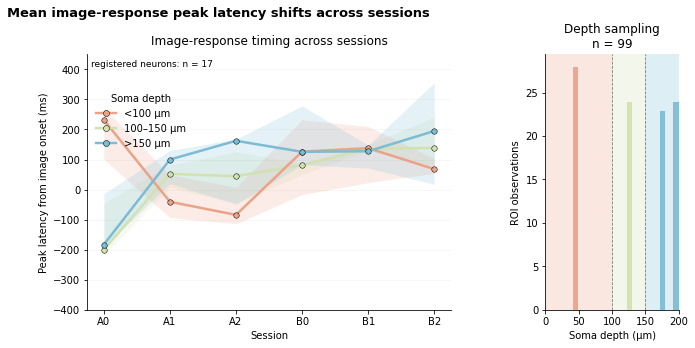

In [28]:
# Composite figure: longitudinal peak latency + depth distribution.

fig = plt.figure(figsize=(10.6, 4.7))
gs = fig.add_gridspec(1, 2, width_ratios=[3.4, 1.25], wspace=0.38)
ax = fig.add_subplot(gs[0, 0])
ax_depth = fig.add_subplot(gs[0, 1])

xmap = {label: i for i, label in enumerate(available_labels)}
xs = np.arange(len(available_labels))

# ---------- longitudinal peak-latency panel ----------
if len(tracked):
    # Individual longitudinal neurons.
    for (_, _), cell in tracked.groupby(
        ["subject_id", "global_cell_id"], observed=True
    ):
        cell = cell.copy()
        cell["x"] = cell["session_label"].map(xmap)
        cell = cell[cell["x"].notna()].sort_values("x")
        if len(cell) < 2:
            continue

        depth_group = str(cell["cell_depth_group"].iloc[0])
        color = DEPTH_COLOR[depth_group]

#         ax.plot(
#             cell["x"],
#             1000.0 * cell["peak_latency_s"],
#             "-o",
#             color=color,
#             alpha=0.30,
#             lw=0.9,
#             ms=3.3,
#             markeredgewidth=0,
#             zorder=1,
#         )

    # Depth-group medians at each session.
#     for depth_group in map(str, DEPTH_GROUP_ORDER):
#         sub = tracked[tracked["cell_depth_group"].astype(str) == depth_group]
#         if sub.empty:
#             continue

#         med = (
#             sub.groupby("session_label", observed=True)["peak_latency_s"]
#             .median()
#             .reindex(available_labels)
#         )

#         ax.plot(
#             xs,
#             1000.0 * med.to_numpy(dtype=float),
#             "-o",
#             color=DEPTH_COLOR[depth_group],
#             lw=2.8,
#             ms=7,
#             markeredgecolor="black",
#             markeredgewidth=0.6,
#             zorder=5,
#             label=depth_group,
#         )
for depth_group, sub in depth_session_summary.groupby("depth_group", observed=True):
    sub = sub.sort_values("session_order")

    x = sub["session_order"].to_numpy()
    y = 1000 * sub["median_peak_latency_s"].to_numpy()
    ylo = 1000 * sub["q25_peak_latency_s"].to_numpy()
    yhi = 1000 * sub["q75_peak_latency_s"].to_numpy()

    color = DEPTH_COLOR[depth_group]

    ax.fill_between(
        x,
        ylo,
        yhi,
        color=color,
        alpha=0.20,
        linewidth=0,
        zorder=1,
    )

    ax.plot(
        x,
        y,
        "-o",
        color=color,
        linewidth=2.5,
        markersize=5.5,
        markerfacecolor=color,
        markeredgecolor="black",
        markeredgewidth=0.5,
        label=depth_group,
        zorder=3,
    )
    
ax.set(
    xticks=xs,
    xticklabels=available_labels,
    xlabel="Session",
    ylabel="Peak latency from image onset (ms)",
    xlim=(-0.25, len(available_labels) - 0.75),
)
ax.set_ylim(1000 * PEAK_WINDOW_S[0], 1000 * PEAK_WINDOW_S[1])
ax.set_title("Image-response timing across sessions", pad=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.16, lw=0.7)

n_tracked_cells = (
    tracked[["subject_id", "global_cell_id"]].drop_duplicates().shape[0]
    if len(tracked) else 0
)
ax.text(
    0.01, 0.98,
    f"registered neurons: n = {n_tracked_cells}",
    transform=ax.transAxes,
    ha="left", va="top", fontsize=9,
)

# ---------- depth-distribution panel ----------
depth_source = rois[
    rois["included"].astype(bool)
    & np.isfinite(pd.to_numeric(rois["depth_um"], errors="coerce"))
].copy()
depth_source["depth_um"] = pd.to_numeric(depth_source["depth_um"], errors="coerce")

if DEPTH_HIST_UNIT == "unique_cells":
    # Registered repeated observations collapse through cell_id/global identity;
    # unregistered observations remain session-specific rather than inventing matches.
    depth_plot = (
        depth_source.groupby(["subject_id", "cell_id"], observed=True, as_index=False)
        .agg(depth_um=("depth_um", "median"))
    )
    depth_ylabel = "Unique cell IDs"
elif DEPTH_HIST_UNIT == "roi_observations":
    depth_plot = depth_source[["subject_id", "session_id", "cell_id", "depth_um"]].copy()
    depth_ylabel = "ROI observations"
else:
    raise ValueError("DEPTH_HIST_UNIT must be 'roi_observations' or 'unique_cells'.")

depth_max = max(200.0, float(np.nanmax(depth_plot["depth_um"])) + 10.0)
spans = [
    (0.0, 100.0, str(DEPTH_GROUP_ORDER[0])),
    (100.0, 150.0, str(DEPTH_GROUP_ORDER[1])),
    (150.0, depth_max, str(DEPTH_GROUP_ORDER[2])),
]
for lo, hi, group in spans:
    ax_depth.axvspan(lo, hi, color=DEPTH_COLOR[group], alpha=0.25, lw=0)

bin_width = 10.0
bins = np.arange(
    0.0,
    np.ceil(depth_max / bin_width) * bin_width + bin_width,
    bin_width,
)
counts, edges = np.histogram(depth_plot["depth_um"].to_numpy(dtype=float), bins=bins)

for count, left, right in zip(counts, edges[:-1], edges[1:]):
    center = 0.5 * (left + right)
    group = depth_group_from_um(center)
    ax_depth.bar(
        center,
        count,
        width=(right - left) * 0.92,
        color=DEPTH_COLOR[group],
        edgecolor="white",
        linewidth=0.6,
        alpha=0.92,
    )

for boundary in (100, 150):
    ax_depth.axvline(boundary, color="0.35", lw=0.8, ls="--", alpha=0.8)

ax_depth.set(
    xlabel="Soma depth (µm)",
    ylabel=depth_ylabel,
    xlim=(0, depth_max),
)
ax_depth.set_title(f"Depth sampling\nn = {len(depth_plot)}", pad=7)
ax_depth.spines[["top", "right"]].set_visible(False)

legend_handles = [
    Line2D(
        [0], [0],
        color=DEPTH_COLOR[str(group)],
        marker="o",
        lw=2.4,
        ms=6,
        markeredgecolor="black",
        markeredgewidth=0.5,
        label=str(group),
    )
    for group in DEPTH_GROUP_ORDER
]
ax.legend(
    handles=legend_handles,
    title="Soma depth",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(0.0, 0.88),
)

fig.suptitle(
    "Mean image-response peak latency shifts across sessions",
    x=0.02, y=1.02, ha="left", fontsize=13, fontweight="bold",
)
plt.show()

# Optional export:
# fig.savefig("ASAP8_image_peak_latency_by_depth.pdf", bbox_inches="tight", transparent=True)
# fig.savefig("ASAP8_image_peak_latency_by_depth.png", dpi=600, bbox_inches="tight", transparent=True)


,swc_file,soma_depth_um,soma_source,depth_group
0,slap2_super_stack_ch1-000.swc,36.000,root fallback,<100 µm
1,slap2_super_stack_ch1-001.swc,37.500,root fallback,<100 µm
2,slap2_super_stack_ch1-002.swc,64.500,root fallback,<100 µm
3,slap2_super_stack_ch1-003.swc,103.875,root fallback,100–150 µm
4,slap2_super_stack_ch1-009.swc,111.500,root fallback,100–150 µm
5,slap2_super_stack_ch1-014.swc,116.000,root fallback,100–150 µm
6,slap2_super_stack_ch1-011.swc,123.000,root fallback,100–150 µm
7,slap2_super_stack_ch1-013.swc,134.500,root fallback,100–150 µm
8,slap2_super_stack_ch1-004.swc,135.750,root fallback,100–150 µm
9,slap2_super_stack_ch1-007.swc,145.500,root fallback,100–150 µm



Reconstructed neurons: n = 16
Depth range: 36.0–277.9 µm

Depth groups:
depth_group
<100 µm       3
100–150 µm    7
>150 µm       6
Name: count, dtype: int64


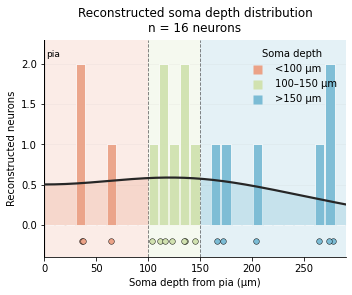

In [29]:
# %% SWC soma-depth distribution
from pathlib import Path
from scipy.stats import gaussian_kde
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ---------------------------------------------------------------------
# Parameters
# ---------------------------------------------------------------------

SWC_DIR = Path(
    r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics"
    r"\ASAP7\852841\852841_2026-08-01_16-17-34"
    r"\852841_2026-08-01_16-17-34"
    r"\slap2\dynamic_data\reference_stack"
    r"\super_stack_qc\full_reference_merge\Reconstructions"
)

# Same depth groups used elsewhere in the analysis.
DEPTH_GROUP_ORDER = ["<100 µm", "100–150 µm", ">150 µm"]

DEPTH_COLOR = {
    "<100 µm": "#EBA287",
    "100–150 µm": "#d1e2b0",
    ">150 µm": "#7bbcd5",
}

BIN_WIDTH_UM = 10.0


def depth_group_from_um(depth):
    if depth < 100:
        return "<100 µm"
    elif depth <= 150:
        return "100–150 µm"
    else:
        return ">150 µm"


# ---------------------------------------------------------------------
# Read SWCs and extract soma Z
# ---------------------------------------------------------------------

records = []

# rglob also finds SWCs in subdirectories, if present.
swc_files = sorted(SWC_DIR.rglob("*.swc"))

if not swc_files:
    raise FileNotFoundError(f"No .swc files found in:\n{SWC_DIR}")


for swc_path in swc_files:

    try:
        swc = pd.read_csv(
            swc_path,
            sep=r"\s+",
            comment="#",
            header=None,
            names=[
                "node_id",
                "type",
                "x",
                "y",
                "z",
                "radius",
                "parent_id",
            ],
        )
    except Exception as exc:
        print(f"Could not read {swc_path.name}: {exc}")
        continue

    # Ensure numeric coordinates.
    for col in ["node_id", "type", "x", "y", "z", "radius", "parent_id"]:
        swc[col] = pd.to_numeric(swc[col], errors="coerce")

    swc = swc.dropna(subset=["z"])

    if swc.empty:
        print(f"Skipping {swc_path.name}: no valid Z coordinates")
        continue

    # SWC type 1 = soma.
    soma = swc[swc["type"] == 1]

    if not soma.empty:
        # Multiple soma nodes are common in some SWCs.
        soma_z = float(soma["z"].median())
        soma_source = "type 1 soma"

    else:
        # Fall back to the root node.
        root = swc[swc["parent_id"] == -1]

        if root.empty:
            print(f"Skipping {swc_path.name}: no soma or root node")
            continue

        soma_z = float(root["z"].iloc[0])
        soma_source = "root fallback"

    records.append(
        {
            "swc_file": swc_path.name,
            "soma_depth_um": soma_z,
            "soma_source": soma_source,
        }
    )


soma_depths = pd.DataFrame(records)

if soma_depths.empty:
    raise RuntimeError("No usable soma positions could be extracted.")

soma_depths["depth_group"] = soma_depths["soma_depth_um"].map(
    depth_group_from_um
)


# ---------------------------------------------------------------------
# Inspect extracted positions
# ---------------------------------------------------------------------

display(
    soma_depths
    .sort_values("soma_depth_um")
    .reset_index(drop=True)
)

print(
    f"\nReconstructed neurons: n = {len(soma_depths)}\n"
    f"Depth range: "
    f"{soma_depths['soma_depth_um'].min():.1f}–"
    f"{soma_depths['soma_depth_um'].max():.1f} µm"
)

print("\nDepth groups:")
print(
    soma_depths["depth_group"]
    .value_counts()
    .reindex(DEPTH_GROUP_ORDER, fill_value=0)
)


# ---------------------------------------------------------------------
# Sanity check coordinate orientation
# ---------------------------------------------------------------------

if (soma_depths["soma_depth_um"] < 0).any():
    print(
        "\nWARNING: Negative soma Z positions detected.\n"
        "This code assumes Z = 0 µm at pia and positive Z extends deeper "
        "into cortex. Inspect the values before interpreting the plot."
    )


# ---------------------------------------------------------------------
# Histogram
# ---------------------------------------------------------------------

min_depth = min(0.0, float(soma_depths["soma_depth_um"].min()))

depth_max = max(
    200.0,
    np.ceil(soma_depths["soma_depth_um"].max() / BIN_WIDTH_UM)
    * BIN_WIDTH_UM
    + BIN_WIDTH_UM,
)

bins = np.arange(
    0,
    depth_max + BIN_WIDTH_UM,
    BIN_WIDTH_UM,
)

counts, edges = np.histogram(
    soma_depths["soma_depth_um"],
    bins=bins,
)


# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(5.0, 4.2))


# ----- depth-group background -----

spans = [
    (0, 100, "<100 µm"),
    (100, 150, "100–150 µm"),
    (150, depth_max, ">150 µm"),
]

for lo, hi, group in spans:
    ax.axvspan(
        lo,
        hi,
        color=DEPTH_COLOR[group],
        alpha=0.20,
        lw=0,
        zorder=0,
    )


# ----- histogram bars -----

for count, left, right in zip(
    counts,
    edges[:-1],
    edges[1:],
):
    center = (left + right) / 2
    group = depth_group_from_um(center)

    ax.bar(
        center,
        count,
        width=(right - left) * 0.90,
        color=DEPTH_COLOR[group],
        edgecolor="white",
        linewidth=0.8,
        alpha=0.95,
        zorder=2,
    )

# ----- smoothed soma-depth density -----

depth_values = (
    soma_depths["soma_depth_um"]
    .dropna()
    .to_numpy(dtype=float)
)

# Smooth x-grid for KDE.
x_density = np.linspace(0, depth_max, 600)

if len(depth_values) >= 3 and np.nanstd(depth_values) > 0:

    # Reflect across pia (depth = 0) to reduce KDE boundary bias.
    # Without this, an ordinary KDE artificially spreads density above the pia.
    reflected_depths = np.concatenate([
        depth_values,
        -depth_values,
    ])

    kde = gaussian_kde(
        reflected_depths,
        bw_method="scott",
    )

    # Reflection splits probability mass between +/- depth, hence * 2.
    density = 2.0 * kde(x_density)

    # Scale probability density to histogram-count units:
    # density × N × histogram bin width.
    density_counts = (
        density
        * len(depth_values)
        * BIN_WIDTH_UM
    )

    # Main KDE outline.
    ax.plot(
        x_density,
        density_counts,
        color="0.15",
        lw=2.2,
        zorder=6,
    )

    # Fill underneath the KDE according to depth group.
    density_spans = [
        (0, 100, "<100 µm"),
        (100, 150, "100–150 µm"),
        (150, depth_max, ">150 µm"),
    ]

    for lo, hi, group in density_spans:

        mask = (
            (x_density >= lo)
            & (x_density <= hi)
        )

        ax.fill_between(
            x_density[mask],
            0,
            density_counts[mask],
            color=DEPTH_COLOR[group],
            alpha=0.28,
            linewidth=0,
            zorder=4,
        )
# ----- cortical-depth boundaries -----

for boundary in [100, 150]:
    ax.axvline(
        boundary,
        color="0.35",
        linestyle="--",
        linewidth=0.9,
        alpha=0.8,
        zorder=3,
    )


# ----- individual reconstructed neurons -----
#
# Add a small rug below the histogram so the actual soma locations
# remain visible regardless of the histogram binning.

ymax = max(int(counts.max()), 1)
rug_y = -0.10 * ymax

for _, row in soma_depths.iterrows():

    ax.scatter(
        row["soma_depth_um"],
        rug_y,
        s=32,
        color=DEPTH_COLOR[row["depth_group"]],
        edgecolor="black",
        linewidth=0.45,
        clip_on=False,
        zorder=5,
    )


# ----- pia -----

ax.axvline(
    0,
    color="black",
    linewidth=1.1,
    zorder=4,
)

ax.text(
    2,
    ymax * 1.03,
    "pia",
    ha="left",
    va="bottom",
    fontsize=9,
)


# ---------------------------------------------------------------------
# Formatting
# ---------------------------------------------------------------------

ax.set(
    xlabel="Soma depth from pia (µm)",
    ylabel="Reconstructed neurons",
    xlim=(0, depth_max),
)

ax.set_ylim(
    rug_y * 2,
    ymax * 1.15,
)

ax.set_title(
    f"Reconstructed soma depth distribution\n"
    f"n = {len(soma_depths)} neurons",
    pad=8,
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.12, linewidth=0.7)


# ----- legend -----

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="none",
        markerfacecolor=DEPTH_COLOR[group],
        markeredgecolor="none",
        markersize=9,
        label=group,
    )
    for group in DEPTH_GROUP_ORDER
]

ax.legend(
    handles=legend_handles,
    title="Soma depth",
    frameon=False,
    loc="upper right",
)


plt.tight_layout()
plt.show()


# Optional export:
# fig.savefig(
#     "ASAP7_reconstructed_soma_depths.pdf",
#     bbox_inches="tight",
#     transparent=True,
# )
#
# fig.savefig(
#     "ASAP7_reconstructed_soma_depths.png",
#     dpi=600,
#     bbox_inches="tight",
#     transparent=True,
# )

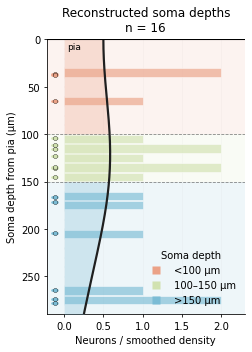

In [21]:
# %% Vertical soma-depth distribution:
# horizontal histogram + KDE + exact soma positions

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D


# ---------------------------------------------------------------------
# Parameters
# ---------------------------------------------------------------------

DEPTH_GROUP_ORDER = ["<100 µm", "100–150 µm", ">150 µm"]

DEPTH_COLOR = {
    "<100 µm": "#EBA287",
    "100–150 µm": "#d1e2b0",
    ">150 µm": "#7bbcd5",
}

BIN_WIDTH_UM = 10.0

depth_values = (
    soma_depths["soma_depth_um"]
    .dropna()
    .to_numpy(dtype=float)
)

depth_max = max(
    200,
    np.ceil(depth_values.max() / BIN_WIDTH_UM) * BIN_WIDTH_UM
    + BIN_WIDTH_UM,
)


def depth_group_from_um(depth):
    if depth < 100:
        return "<100 µm"
    elif depth <= 150:
        return "100–150 µm"
    else:
        return ">150 µm"


# ---------------------------------------------------------------------
# Horizontal histogram
# ---------------------------------------------------------------------

bins = np.arange(
    0,
    depth_max + BIN_WIDTH_UM,
    BIN_WIDTH_UM,
)

counts, edges = np.histogram(
    depth_values,
    bins=bins,
)

bin_centers = 0.5 * (edges[:-1] + edges[1:])


# ---------------------------------------------------------------------
# Boundary-corrected KDE
# ---------------------------------------------------------------------

y_density = np.linspace(0, depth_max, 800)

if len(depth_values) >= 3 and np.nanstd(depth_values) > 0:

    # Reflect around pia to avoid density leaking into negative depth.
    reflected = np.concatenate([
        depth_values,
        -depth_values,
    ])

    kde = gaussian_kde(
        reflected,
        bw_method="scott",
    )

    density = 2.0 * kde(y_density)

    # Scale KDE into histogram-count units.
    density_counts = (
        density
        * len(depth_values)
        * BIN_WIDTH_UM
    )

else:
    density_counts = np.zeros_like(y_density)


# ---------------------------------------------------------------------
# Figure
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(3.6, 5.0))


# ---------------------------------------------------------------------
# Depth-group background
# ---------------------------------------------------------------------

spans = [
    (0, 100, "<100 µm"),
    (100, 150, "100–150 µm"),
    (150, depth_max, ">150 µm"),
]

for lo, hi, group in spans:
    ax.axhspan(
        lo,
        hi,
        color=DEPTH_COLOR[group],
        alpha=0.12,
        lw=0,
        zorder=0,
    )


# ---------------------------------------------------------------------
# Horizontal histogram bars
# ---------------------------------------------------------------------

for count, center, bottom, top in zip(
    counts,
    bin_centers,
    edges[:-1],
    edges[1:],
):

    group = depth_group_from_um(center)

    ax.barh(
        center,
        count,
        height=(top - bottom) * 0.88,
        left=0,
        color=DEPTH_COLOR[group],
        alpha=0.65,
        edgecolor="white",
        linewidth=0.7,
        zorder=2,
    )


# ---------------------------------------------------------------------
# Smoothed density
# ---------------------------------------------------------------------

# Colored fill under KDE.
for lo, hi, group in spans:

    mask = (
        (y_density >= lo)
        & (y_density <= hi)
    )

    ax.fill_betweenx(
        y_density[mask],
        0,
        density_counts[mask],
        color=DEPTH_COLOR[group],
        alpha=0.28,
        linewidth=0,
        zorder=3,
    )

# KDE outline.
ax.plot(
    density_counts,
    y_density,
    color="0.12",
    lw=2.2,
    zorder=5,
)


# ---------------------------------------------------------------------
# Exact soma positions
# ---------------------------------------------------------------------

# Put exact observations slightly to the left of zero.
max_x = max(
    float(counts.max()),
    float(np.nanmax(density_counts)),
    1,
)

rug_x = -0.06 * max_x

for depth in depth_values:

    group = depth_group_from_um(depth)

    # Small horizontal tick at exact soma Z.
    ax.plot(
        [
            rug_x - 0.018 * max_x,
            rug_x + 0.018 * max_x,
        ],
        [depth, depth],
        color=DEPTH_COLOR[group],
        lw=2.6,
        solid_capstyle="round",
        zorder=7,
        clip_on=False,
    )

    ax.scatter(
        rug_x,
        depth,
        s=18,
        color=DEPTH_COLOR[group],
        edgecolor="black",
        linewidth=0.35,
        zorder=8,
        clip_on=False,
    )


# ---------------------------------------------------------------------
# Anatomical boundaries
# ---------------------------------------------------------------------

for boundary in [100, 150]:
    ax.axhline(
        boundary,
        color="0.35",
        linestyle="--",
        lw=0.8,
        alpha=0.75,
        zorder=4,
    )

# Pia
ax.axhline(
    0,
    color="black",
    lw=1.1,
    zorder=6,
)

ax.text(
    0.02 * max_x,
    3,
    "pia",
    ha="left",
    va="top",
    fontsize=9,
)


# ---------------------------------------------------------------------
# Formatting
# ---------------------------------------------------------------------

# Anatomical convention: pia at top, deeper cortex downward.
ax.set_ylim(depth_max, 0)

ax.set_xlim(
    rug_x - 0.05 * max_x,
    max_x * 1.15,
)

ax.set_ylabel("Soma depth from pia (µm)")
ax.set_xlabel("Neurons / smoothed density")

ax.set_title(
    f"Reconstructed soma depths\nn = {len(depth_values)}",
    pad=8,
)

ax.spines[["top", "right"]].set_visible(False)

ax.grid(
    axis="x",
    alpha=0.10,
    lw=0.6,
)

ax.tick_params(axis="both", length=3)


# ---------------------------------------------------------------------
# Legend
# ---------------------------------------------------------------------

legend_handles = [
    Line2D(
        [0], [0],
        marker="s",
        linestyle="none",
        markerfacecolor=DEPTH_COLOR[group],
        markeredgecolor="none",
        markersize=8,
        label=group,
    )
    for group in DEPTH_GROUP_ORDER
]

ax.legend(
    handles=legend_handles,
    title="Soma depth",
    frameon=False,
    loc="lower right",
)


plt.tight_layout()
plt.show()


# Optional export:
# fig.savefig(
#     "ASAP7_soma_depth_distribution_vertical.pdf",
#     bbox_inches="tight",
#     transparent=True,
# )
#
# fig.savefig(
#     "ASAP7_soma_depth_distribution_vertical.png",
#     dpi=600,
#     bbox_inches="tight",
#     transparent=True,
# )